In [ ]:
import numpy as np

import matplotlib.pyplot as plt

## Part 1: Driving Home

#### **Problem Description**
You are simulating a daily commute where you predict the total time it will take to get home. Predictions are updated using:

- **Monte Carlo Method**: Updates predictions after the full journey is completed.
- **Temporal Difference Method**: Updates predictions incrementally after each step.

#### **Instructions**
1. **Set up the environment:**
   - Define a sequence of states and their corresponding predicted travel times:

     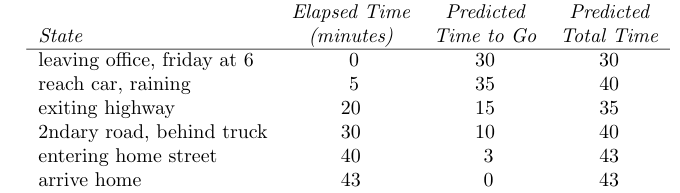

   - Assume the reward is the elapsed time for each step.

2. **Monte Carlo Implementation:**
   - Complete the following function to update the predictions for all states after the journey is completed:


In [8]:
# Monte Carlo Implementation
# Update predictions based on total elapsed times

def mc_update(predictions, elapsed, alpha):
    returns = [elapsed[-1] - t for t in elapsed]  # Total time to go from each state
    for idx, _ in enumerate(predictions):
        predictions[idx] += alpha * (returns[idx] - predictions[idx])
    return predictions

3. **Temporal Difference Implementation:**

Complete the following function to update predictions incrementally after each state transition:

In [9]:
# Temporal Difference Implementation
# Update predictions based on temporal differences
def td_update(predictions, elapsed, alpha, gamma):
    for idx in range(len(predictions) - 1):
        reward = elapsed[idx + 1] - elapsed[idx]  # Elapsed time between states
        predictions[idx] += alpha * (reward + gamma * predictions[idx + 1] - predictions[idx])
    return predictions


4. **Run and Compare:**
   - Use the provided data to compare MC and TD updates.
   - Plot the results for visual comparison.


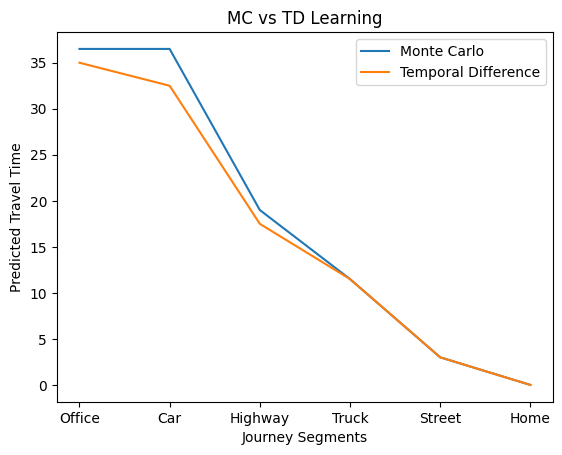

In [10]:


states = ["Office", "Car", "Highway", "Truck", "Street", "Home"]
predicted_durations = [30, 35, 15, 10, 3, 0]
elapsed_time = [0, 5, 20, 30, 40, 43]
learning_rate = 0.5

updated_mc = mc_update(predicted_durations.copy(), elapsed_time, learning_rate)
updated_td = td_update(predicted_durations.copy(), elapsed_time, learning_rate, gamma=1.0)

plt.plot(states, updated_mc, label="Monte Carlo")
plt.plot(states, updated_td, label="Temporal Difference")
plt.xlabel("Journey Segments")
plt.ylabel("Predicted Travel Time")
plt.title("MC vs TD Learning")
plt.legend()
plt.show()

## Part 2: Cliff Walking

#### Problem Description
You will implement **SARSA** and **Q-Learning** on the **Cliff Walking** gridworld problem.

- **Environment:**
  - A 4x12 gridworld where the agent starts at the bottom-left corner and must reach the bottom-right corner.
  - The "cliff" is the set of cells between the start and goal along the bottom row (except the corners).
  - Stepping into the cliff incurs a reward of \(-100\) and resets the agent to the start position. All other moves have a reward of \(-1\).
  ![Alt Text](Cliff_Walking.png)

#### Instructions
1. **Set up the environment:**
   - Complete the following class to represent the gridworld:

In [11]:
class GridEnv:
    def __init__(self):
        self.rows, self.cols = 4, 12
        self.start, self.goal = (3, 0), (3, 11)
        self.cliff = [(3, i) for i in range(1, 11)]
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}  # Up, Down, Left, Right

    def step(self, state, action):
        r, c = state
        dr, dc = self.actions[action]
        next_state = (max(0, min(self.rows - 1, r + dr)), max(0, min(self.cols - 1, c + dc)))

        if next_state in self.cliff:
            return self.start, -100, False
        elif next_state == self.goal:
            return next_state, 0, True
        else:
            return next_state, -1, False

    def reset(self):
        return self.start



2. **SARSA Implementation:**
   - Complete the following function for SARSA learning:


In [12]:
def sarsa(env, episodes, alpha, gamma, epsilon):
    q_table = np.zeros((env.rows, env.cols, 4))

    for _ in range(episodes):
        state = env.reset()
        action = epsilon_policy(q_table, state, epsilon)
        done = False

        while not done:
            next_state, reward, done = env.step(state, action)
            next_action = epsilon_policy(q_table, next_state, epsilon)
            q_table[state][action] += alpha * (
                reward + gamma * q_table[next_state][next_action] - q_table[state][action]
            )
            state, action = next_state, next_action

    return q_table


3. **Q-Learning Implementation:**
   - Complete the following function for Q-Learning:



In [13]:
def q_learning(env, episodes, alpha, gamma, epsilon):
    q_table = np.zeros((env.rows, env.cols, 4))

    for _ in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = epsilon_policy(q_table, state, epsilon)
            next_state, reward, done = env.step(state, action)
            q_table[state][action] += alpha * (
                reward + gamma * np.max(q_table[next_state]) - q_table[state][action]
            )
            state = next_state

    return q_table


4. **Policy and Evaluation:**
   - Train both algorithms and compare their performance using cumulative rewards.

In [14]:
# Evaluate both algorithms
env = GridEnv()
alpha, gamma, epsilon, episodes = 0.1, 1.0, 0.1, 500

q_sarsa = sarsa(env, episodes, alpha, gamma, epsilon)
q_qlearning = q_learning(env, episodes, alpha, gamma, epsilon)

# Plot cumulative rewards (implement reward tracking in training loops)
plt.plot(range(episodes), rewards_sarsa, label="SARSA")
plt.plot(range(episodes), rewards_qlearning, label="Q-Learning")
plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("SARSA vs Q-Learning Performance")
plt.legend()
plt.show()

NameError: name 'epsilon_policy' is not defined

### Discussion
1.
2.


Part 2: Tasks
Task 1: Define the Environment
Set up the sequence of states, elapsed times, and initial predictions.


In [ ]:
# Environment setup
states = ["Office", "Car", "Highway", "Truck", "Street", "Home"]
elapsed_times = [0, 5, 20, 30, 40, 43]  # Elapsed time at each state
predicted_durations = [30, 35, 15, 10, 3, 0]  # Initial predictions for time to go

# Learning parameters
alpha = 0.5  # Step-size parameter
gamma = 1.0  # Discount factor


In [ ]:
Task 2: Implement the Monte Carlo Update Function
The mc_update function updates the predictions based on the return 
𝐺
𝑡
G 
t
​
 , which is the total time from each state to the end of the journey.



#### Monte Carlo Method Update Rule:
$$
V(S_t) \leftarrow V(S_t) + \alpha \big(G_t - V(S_t)\big)
$$

Where:
- $\alpha$ : Step-size parameter.
- $G_t$: Total return from state \( S_t \).

---

#### Total Return in Monte Carlo:
$
G_t = \text{elapsed time at the final state} - \text{elapsed time at state } S_t
$

---

### Monte Carlo Method: State Value Update
The Monte Carlo update rule for state value \( V(S_t) \) is:
\[
V(S_t) \leftarrow V(S_t) + \alpha \big(G_t - V(S_t)\big)
\]
Where:
- \( G_t \) is the total return (cumulative reward) from state \( S_t \).
- \( \alpha \) is the learning rate.

---

### Return Calculation for Monte Carlo
The return \( G_t \) for a state \( S_t \) in a finite-horizon episode is:
\[
G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}
\]
Where:
- \( T \) is the final time step in the episode.

---

In [ ]:
def mc_update(predictions, elapsed, alpha):
    """
    Updates predictions using the Monte Carlo method.

    Args:
        predictions (list): Predicted durations for each state.
        elapsed (list): Elapsed time at each state.
        alpha (float): Step-size parameter.

    Returns:
        list: Updated predictions.
    """
    # Your code here



#### Temporal Difference (TD) Method Update Rule:
$$
V(S_t) \leftarrow V(S_t) + \alpha \big( R_{t+1} + \gamma V(S_{t+1}) - V(S_t) \big)
$$

Where:
- \( R_{t+1} \): Reward for the transition from \( S_t \) to \( S_{t+1} \).
- \( \gamma \): Discount factor.

---

#### TD Error:
$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

---


### Temporal Difference Method: State Value Update
The Temporal Difference (TD) update rule is:
\[
V(S_t) \leftarrow V(S_t) + \alpha \big( R_{t+1} + \gamma V(S_{t+1}) - V(S_t) \big)
\]
Where:
- \( R_{t+1} \) is the immediate reward.
- \( \gamma \) is the discount factor (e.g., \( \gamma = 1 \) for this lab).

---



### Temporal Difference Error
The Temporal Difference error (\( \delta_t \)) is given by:
\[
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
\]
This measures the difference between the predicted and actual returns.

---

Task 3: Implement the Temporal Difference Update Function
The td_update function updates predictions incrementally after each state transition using the temporal difference error.


In [ ]:
def td_update(predictions, elapsed, alpha, gamma):
    """
    Updates predictions using the Temporal Difference method.

    Args:
        predictions (list): Predicted durations for each state.
        elapsed (list): Elapsed time at each state.
        alpha (float): Step-size parameter.
        gamma (float): Discount factor.

    Returns:
        list: Updated predictions.
    """
    # Your code here


Task 4: Use the Update Functions
Call the mc_update and td_update functions using the initial predictions and compare the results.



In [ ]:

# Apply Monte Carlo updates
updated_mc = mc_update(predicted_durations.copy(), elapsed_times, alpha)

# Apply Temporal Difference updates
updated_td = td_update(predicted_durations.copy(), elapsed_times, alpha, gamma)

# Print results
print("Monte Carlo Updated Predictions:", updated_mc)
print("Temporal Difference Updated Predictions:", updated_td)


Task 5: Plot the Results
Visualize the updated predictions to understand the differences between the two methods.



In [ ]:

plt.plot(states, updated_mc, label="Monte Carlo", marker='o')
plt.plot(states, updated_td, label="Temporal Difference", marker='x')
plt.xlabel("States")
plt.ylabel("Predicted Time to Go")
plt.title("MC vs TD Updates")
plt.legend()
plt.grid()
plt.show()


Part 3: Discussion Questions
What are the key differences in how MC and TD methods update predictions?
How does the step-size parameter 
𝛼
α influence the updates for both methods?
What are the advantages and limitations of MC compared to TD in this specific problem?
Why is the discount factor 
𝛾
γ set to 1 in this example?
Which method converges faster in your implementation, and why?



Compare the performance of SARSA and Q-Learning in terms of cumulative rewards.
Part 2: Cliff Walking
Problem Description
You will implement SARSA and Q-Learning on a 4x12 gridworld called the Cliff Walking environment:

The agent starts at the bottom-left corner and must reach the bottom-right corner.
The cells between the start and goal along the bottom row (except the corners) represent a "cliff." Stepping into the cliff:
Resets the agent to the start position.
Incurs a reward of 
−
100
−100.
All other moves have a reward of 
−
1
−1.
Tasks
Task 1: Implement the Grid Environment
Define the environment, including states, actions, rewards, and transitions.

In [ ]:

class CliffWalkingEnv:
    def __init__(self):
        self.rows, self.cols = 4, 12
        self.start, self.goal = (3, 0), (3, 11)
        self.cliff = [(3, i) for i in range(1, 11)]
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}  # Up, Down, Left, Right

    def step(self, state, action):
        """
        Take a step in the environment.

        Args:
            state (tuple): Current state (row, col).
            action (int): Action to take (0=up, 1=down, 2=left, 3=right).

        Returns:
            tuple: (next_state, reward, done)
        """
        r, c = state
        dr, dc = self.actions[action]
        next_state = (max(0, min(self.rows - 1, r + dr)), max(0, min(self.cols - 1, c + dc)))
        
        if next_state in self.cliff:
            return self.start, -100, False
        elif next_state == self.goal:
            return next_state, 0, True
        else:
            return next_state, -1, False

    def reset(self):
        return self.start


### SARSA Update Rule
The SARSA (on-policy TD control) update rule is:
\[
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big( R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \big)
\]
Where:
- \( Q(S_t, A_t) \) is the action-value function for state \( S_t \) and action \( A_t \).
- \( R_{t+1} \) is the reward received for transitioning to \( S_{t+1} \).
- \( \gamma \) is the discount factor.

---


#### SARSA Update Rule:
$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big( R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \big)
$$

---


Task 2: Implement the SARSA Update Function
The SARSA update function adjusts the Q-values based on the state-action pair observed and the next state-action pair:

In [ ]:

def sarsa_update(q_table, state, action, reward, next_state, next_action, alpha, gamma):
    """
    Performs a SARSA update.

    Args:
        q_table (np.ndarray): The Q-table.
        state (tuple): Current state.
        action (int): Current action.
        reward (float): Reward received.
        next_state (tuple): Next state.
        next_action (int): Next action.
        alpha (float): Learning rate.
        gamma (float): Discount factor.

    Returns:
        None
    """
    # Your code here


### Q-Learning Update Rule
The Q-Learning (off-policy TD control) update rule is:
\[
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big( R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t) \big)
\]
Where:
- \( \max_a Q(S_{t+1}, a) \) represents the maximum estimated future reward for the next state \( S_{t+1} \).

---

Task 3: Implement the Q-Learning Update Function
The Q-Learning update function adjusts the Q-values based on the state-action pair observed and the maximum future Q-value:
#### Q-Learning Update Rule:
$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big( R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \big)
$$

---

In [ ]:


def q_learning_update(q_table, state, action, reward, next_state, alpha, gamma):
    """
    Performs a Q-Learning update.

    Args:
        q_table (np.ndarray): The Q-table.
        state (tuple): Current state.
        action (int): Current action.
        reward (float): Reward received.
        next_state (tuple): Next state.
        alpha (float): Learning rate.
        gamma (float): Discount factor.

    Returns:
        None
    """
    # Your code here




### Exploration-Exploitation Strategy: \( \epsilon \)-Greedy Policy
The \( \epsilon \)-greedy policy chooses an action \( a \) as follows:
\[
P(a) =
\begin{cases}
1 - \epsilon + \frac{\epsilon}{|A|}, & \text{if } a = \arg\max_a Q(S, a) \\
\frac{\epsilon}{|A|}, & \text{otherwise}
\end{cases}
\]
Where:
- \( \epsilon \) is the exploration probability.
- \( |A| \) is the size of the action space.


#### Epsilon-Greedy Policy:
$$
\pi(a|s) =

1 - \epsilon + \frac{\epsilon}{|\mathcal{A}(s)| & \text{if } a = \text{argmax}_{a'} Q(s, a') \\
\frac{\epsilon}{|\mathcal{A}(s)| & \text{otherwise}
$$

Where:
- \( \epsilon \): Exploration probability.
- \( |\mathcal{A}(s)| \): Number of available actions in state \( s \).

Task 4: Train the Agent Using Both Methods
Train the agent for multiple episodes using both SARSA and Q-Learning, and record the cumulative rewards.




In [ ]:
def epsilon_greedy_policy(q_table, state, epsilon):
    """
    Selects an action using an epsilon-greedy policy.

    Args:
        q_table (np.ndarray): The Q-table.
        state (tuple): Current state.
        epsilon (float): Exploration rate.

    Returns:
        int: Selected action.
    """
    if np.random.rand() < epsilon:
        return np.random.choice(4)
    return np.argmax(q_table[state])

In [ ]:
# SARSA Training
env = CliffWalkingEnv()
q_sarsa = np.zeros((4, 12, 4))  # Initialize Q-table
alpha, gamma, epsilon = 0.1, 1.0, 0.1
episodes, rewards_sarsa = 500, []

for _ in range(episodes):
    state = env.reset()
    action = epsilon_greedy_policy(q_sarsa, state, epsilon)
    total_reward, done = 0, False

    while not done:
        next_state, reward, done = env.step(state, action)
        next_action = epsilon_greedy_policy(q_sarsa, next_state, epsilon)
        sarsa_update(q_sarsa, state, action, reward, next_state, next_action, alpha, gamma)
        state, action = next_state, next_action
        total_reward += reward
    rewards_sarsa.append(total_reward)




In [ ]:
# Q-Learning Training
q_qlearn = np.zeros((4, 12, 4))  # Initialize Q-table
rewards_qlearn = []

for _ in range(episodes):
    state = env.reset()
    total_reward, done = 0, False

    while not done:
        action = epsilon_greedy_policy(q_qlearn, state, epsilon)
        next_state, reward, done = env.step(state, action)
        q_learning_update(q_qlearn, state, action, reward, next_state, alpha, gamma)
        state = next_state
        total_reward += reward
    rewards_qlearn.append(total_reward)

Task 5: Compare the Results
Plot the cumulative rewards for SARSA and Q-Learning over the episodes.



### Policy Improvement
The policy improvement rule is:
\[
\pi(S_t) \leftarrow \arg\max_a Q(S_t, a)
\]
Where:
- \( \pi(S_t) \) is the policy for state \( S_t \).
- \( Q(S_t, a) \) is the action-value function.

---



In [ ]:
plt.plot(range(episodes), rewards_sarsa, label="SARSA", color="blue")
plt.plot(range(episodes), rewards_qlearn, label="Q-Learning", color="orange")
plt.xlabel("Episodes")
plt.ylabel("Cumulative Rewards")
plt.title("Performance: SARSA vs Q-Learning")
plt.legend()
plt.grid()
plt.show()


Discussion Questions
What are the differences in how SARSA and Q-Learning handle exploration and exploitation?
Why does Q-Learning generally perform better in environments where optimal actions need to be learned?
How does the choice of 
𝜖
ϵ influence the agent's learning in both methods?
Compare the cumulative rewards achieved by SARSA and Q-Learning. Which algorithm performs better in this scenario, and why?
How would increasing or decreasing 
𝛼
α (learning rate) affect the convergence of the Q-table?

